  <tr>
        <td>
            <div align="left">
                <font size=25px>
                    <b>Neural Style Transfer using Efficient Net
                    </b>
                </font>
            </div>
        </td>
    </tr>

##Problem Statement:
Neural Style Transfer (NST) is a deep learning technique that combines the artistic style of one image with the content of another image. The goal of this project is to implement NST using a pretrained EfficientNet model. This involves extracting features from content and style images, defining a loss function to balance style and content preservation, and optimizing the image to generate a stylized output.

###Objective:


1.   Extract style and content features using EfficientNet.
2.   Define and minimize style and content loss.
3.   Generate a new image that preserves the content of the input image while adopting the style of the reference image.



##Data Definitions

**1.EfficientNetB0::** IA pretrained convolutional neural network model that is highly efficient in terms of accuracy and size. In this project, it's used to extract features from both the style and content images.

**2.Style Layers:** Layers in the EfficientNet model that capture the artistic style of an image (e.g., texture, color, and patterns).

These layers are:

block1a_activation, block2a_activation, block2b_activation, block3a_activation, block3b_activation, block4a_activation, block4b_activation.

**3.Content Layer:** The layer that captures the spatial and structural information of the content image. For this project:

block5a_activation.

**4.Adam Optimizer:** A gradient-based optimization algorithm known for its efficiency in handling non-convex optimization problems. It is used here to update the generated image.

**5.Gram Matrix:** A matrix representing the correlation between feature maps, used to measure and preserve the style in Neural Style Transfer.

**6.Content Image Preprocessing:**

Resizes the content image while maintaining its aspect ratio.

Normalizes pixel values to a range of [0, 1].

**7.Style Image Preprocessing:** Normalizes pixel values to align with model requirements.

**8.Gram Matrix:** Represents the correlations between feature maps of a layer. It is a mathematical representation of the style of an image.

**9.Style Features:** Extracted using the Gram matrix for each style layer.

**10.Content Features:** Extracted directly from the specified content layer.

**11.Style Loss:** Measures the difference between the Gram matrices of the generated and style images.

**12.Content Loss:** Measures the difference between the content representations of the generated and content images.

**13.Gradient Descent:** Updates the generated image to minimize the total loss.

**14.Training Epochs:** Number of times the model iterates over the optimization process.

**15.Visualization Functions:** Used to display content, style, and generated images.

## 1. Import Libraries and Environment Setup

In [ ]:
# Import necessary libraries
import tensorflow as tf  # TensorFlow for deep learning operations
import numpy as np       # NumPy for numerical computations
import matplotlib.pyplot as plt  # For visualization
import time              # Measure training time
from PIL import Image    # Image loading and manipulation
import ipywidgets as widgets  # For interactive sliders in Jupyter Notebooks
from IPython.display import display  # To display widgets in the notebook

# Import EfficientNet model for feature extraction
base_model_effnet = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet')

# Connecting with google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Define Style and Content Layers

In [ ]:
# Define the style and content layers to be used for feature extraction
style_layer_names = [
    'block1a_activation',
    'block2a_activation',
    'block2b_activation',
    'block3a_activation',
    'block3b_activation',
    'block4a_activation',
    'block4b_activation'
]
num_style_layers = len(style_layer_names)
content_layer_name = ['block5a_activation']

## 3. Build the Feature Extraction Model

In [ ]:
# Function to create the model for extracting style and content features
def get_model(base_model, style_layer_names, content_layer_names):
    outputs = []
    for name in style_layer_names:
        outputs.append(base_model.get_layer(name).output)
    for name in content_layer_names:
        outputs.append(base_model.get_layer(name).output)
    model = tf.keras.models.Model(inputs=base_model.input, outputs=outputs)
    model.trainable = False
    return model

# Build the model
model = get_model(base_model_effnet, style_layer_names, content_layer_name)

# Optimizer for the generated image
optimizer = tf.keras.optimizers.Adam(learning_rate=0.02)

## 4. Image Preprocessing Functions

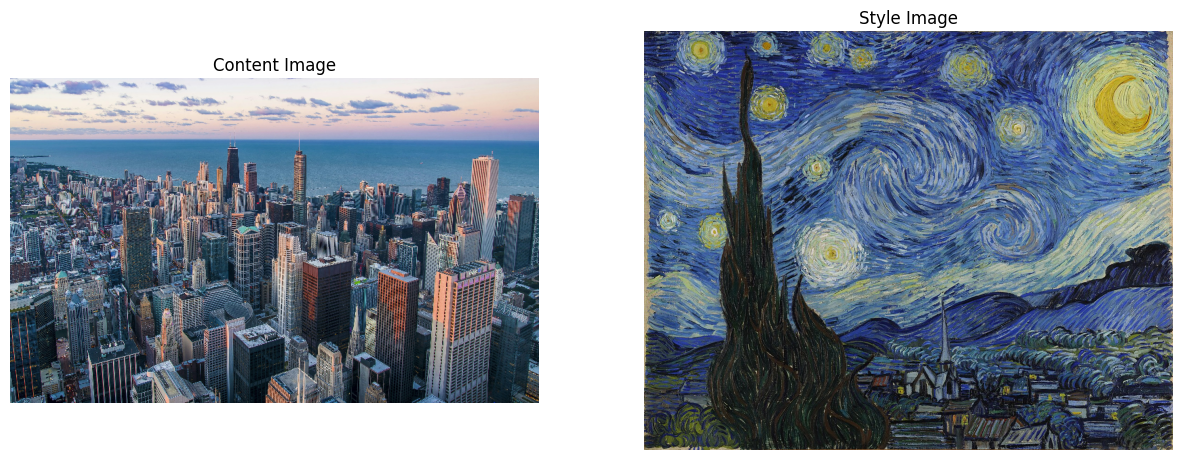

In [ ]:
# Function to load an image
def load_img(path):
    img = Image.open(path).convert('RGB')
    return img

# Function to preprocess the content image
def preprocess_content_img(image):
    image = tf.keras.preprocessing.image.img_to_array(image)
    height, width, _ = image.shape
    aspect_ratio = width / height
    new_width = int(aspect_ratio * 480)
    image = tf.image.resize(image, (480, new_width))
    image = image / 255.0
    return image

# Function to preprocess the style image
def preprocess_style_img(image):
    image = tf.keras.preprocessing.image.img_to_array(image)
    image = image / 255.0
    return image

# Define paths for content and style images
content_img_path = '/content/drive/MyDrive/Colab Notebooks/Neural Style Transfer/NST_Manual_by_EfficientNet/images/content_image/city.jpg'
style_img_path = '/content/drive/MyDrive/Colab Notebooks/Neural Style Transfer/NST_Manual_by_EfficientNet/images/style_image/starry_night.jpg'

# Load and preprocess images
content_img = preprocess_content_img(load_img(content_img_path))
style_img = preprocess_style_img(load_img(style_img_path))

# Display the input images
def plot_images(images, titles=None):
    num_images = len(images)
    fig, axes = plt.subplots(1, num_images, figsize=(15, 10))
    for i, (image, ax) in enumerate(zip(images, axes)):
        ax.imshow(image)
        if titles is not None and i < len(titles):
            ax.set_title(titles[i])
        ax.axis('off')
    plt.show()

plot_images([content_img, style_img], ['Content Image', 'Style Image'])

## 5. Prepare Tensors and Extract Features

In [ ]:
# Function to compute the Gram matrix for style representation
def gram_matrix(input_tensor):
    channels = int(input_tensor.shape[-1])
    a = tf.reshape(input_tensor, [-1, channels])
    gram = tf.matmul(a, a, transpose_a=True)
    return gram / tf.cast(tf.shape(input_tensor)[0] * tf.shape(input_tensor)[1] * tf.shape(input_tensor)[2], tf.float32)

# Function to extract style and content features
def extract_style_content(img_tensor, model):
    preprocessed_img = tf.keras.applications.efficientnet.preprocess_input(img_tensor * 255.0)
    features = model(preprocessed_img)
    style_features = [gram_matrix(feature) for feature in features[:len(style_layer_names)]]
    content_features = features[-1]
    return style_features, content_features

# Prepare input tensors
content_img_tensor = tf.expand_dims(tf.constant(content_img), axis=0)
style_img_tensor = tf.expand_dims(tf.constant(style_img), axis=0)

# Extract target features
_, target_content_output = extract_style_content(content_img_tensor, model)
target_style_outputs, _ = extract_style_content(style_img_tensor, model)

# Initialize the generated image
image = tf.Variable(content_img_tensor, trainable=True)

## 6. Define Loss and Training Functions

In [ ]:
# Function to calculate total loss
def c_loss(style_outputs, content_output, target_style_outputs, target_content_output, style_weight, content_weight):
    style_losses = []
    for i, output in enumerate(style_outputs):
        target_output = target_style_outputs[i]
        style_losses.append(tf.reduce_mean(tf.square(output - target_output)))
    style_loss = tf.reduce_mean(style_losses)
    content_loss = tf.reduce_mean(tf.square(content_output - target_content_output))
    return style_weight * style_loss + content_weight * content_loss

# Function to perform a single training step
@tf.function
def train_step(img, model, target_style_outputs, target_content_output, style_weight, content_weight):
    with tf.GradientTape() as tape:
        style_outputs, content_output = extract_style_content(img, model)
        loss = c_loss(style_outputs, content_output, target_style_outputs, target_content_output, style_weight, content_weight)
    grads = tape.gradient(loss, img)
    optimizer.apply_gradients([(grads, img)])
    img.assign(tf.clip_by_value(img, 0.0, 1.0))

## 7. Training Loop

In [ ]:
from tqdm.notebook import tqdm

def tensor_to_image(tensor):
    tensor = tensor.numpy()
    tensor = (tensor * 255).astype(np.uint8)
    if np.ndim(tensor) > 3:
        assert tensor.shape[0] == 1
        tensor = tensor[0]
    return Image.fromarray(tensor)

#Training a Model
def run_training(style_weight, content_weight, num_epochs=10, steps_per_epoch=100):
    global optimizer
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.02)

    start = time.time()
    for epoch in tqdm(range(num_epochs), desc="Epochs"):
        for step in range(steps_per_epoch):
            train_step(image, model, target_style_outputs, target_content_output, style_weight, content_weight)

        plt.figure(figsize=(12, 10))
        stylized_image = tensor_to_image(image)
        plt.imshow(stylized_image)
        plt.axis('off')
        plt.title(f"Epoch {epoch+1}/{num_epochs}")
        plt.show()
    end = time.time()
    print(f"Total training time: {end - start:.1f} seconds")
    return tensor_to_image(image)

#Creating slider
style_weight_slider = widgets.FloatSlider(value=10.0, min=0.0, max=10.0, step=0.1, description='Style Weight:')
content_weight_slider = widgets.FloatSlider(value=0.2, min=-1.0, max=1.0, step=0.01, description='Content Weight:')
ui = widgets.HBox([style_weight_slider, content_weight_slider])
out = widgets.interactive_output(run_training, {'style_weight': style_weight_slider, 'content_weight': content_weight_slider, 'num_epochs': widgets.fixed(10), 'steps_per_epoch': widgets.fixed(100)})
display(ui, out)

Output()

## 8. Save and Display the Result

In [ ]:
def plot_images(images, titles=None):
    num_images = len(images)
    fig, axes = plt.subplots(1, num_images, figsize=(15, 10))
    for i, (image, ax) in enumerate(zip(images, axes)):
        if isinstance(image, Image.Image):
            image = np.array(image)
        if len(image.shape) > 3:
            image = tf.squeeze(image, axis=0)
        ax.imshow(image)
        if titles is not None and i < len(titles):
            ax.set_title(titles[i])
        ax.axis('off')
    plt.show()

generated_img = tensor_to_image(image)
plot_images([content_img, style_img], ['Content Image', 'Style Image'])
plt.figure(figsize=(12, 12))
plt.imshow(generated_img)
plt.title('Stylized Image')
plt.axis('off')
plt.show()

# Save the Stylized Image
save_path = '/content/drive/MyDrive/Colab Notebooks/Neural Style Transfer/NST_Manual_by_EfficientNet/images/generated images/Style-transfer-image.jpeg'
generated_img.save(save_path)
print(f"Stylized image saved at: {save_path}")

## 9. Conclusion
This project successfully implements a Neural Style Transfer pipeline using EfficientNet for feature extraction. Key steps included:

1.Preprocessing content and style images.

2.Extracting features from style and content layers.

3.Defining loss functions to combine style and content representations.

4.Optimizing the generated image using gradient descent.

The final results demonstrate the artistic potential of deep learning models, blending the structure of a content image with the aesthetic style of another.